In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.shape

(45211, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

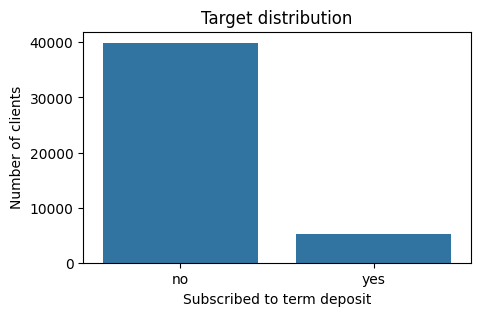

In [6]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="y")
plt.title("Target distribution")
plt.xlabel("Subscribed to term deposit")
plt.ylabel("Number of clients")
plt.show()

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df.select_dtypes(include="object").nunique().sort_values(ascending=False)

job          12
month        12
poutcome      4
education     4
marital       3
contact       3
loan          2
housing       2
default       2
y             2
dtype: int64

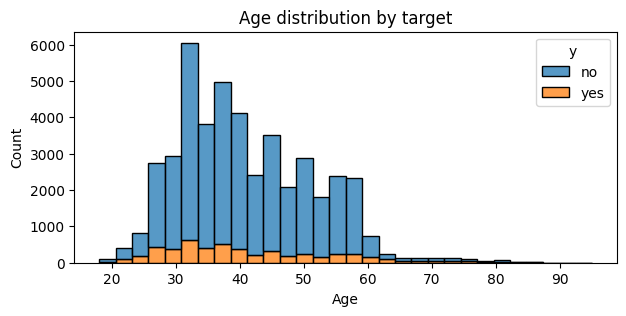

In [9]:
plt.figure(figsize=(7, 3))
sns.histplot(data=df, x="age", hue="y", bins=30, multiple="stack")
plt.title("Age distribution by target")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [10]:
df["target"] = df["y"].map({"no": 0, "yes": 1})
df[["y", "target"]].head()

,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


In [11]:
df_model = df.drop(columns=["y", "duration"])
df_model.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,0


In [12]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

((36168, 15),
 (9043, 15),
 target
 0    0.883018
 1    0.116982
 Name: proportion, dtype: float64,
 target
 0    0.883003
 1    0.116997
 Name: proportion, dtype: float64)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    print(f"Model: {model_name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC:", average_precision_score(y_test, y_proba))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_pipeline.fit(X_train, y_train)

logreg_metrics = evaluate_model(
    log_reg_pipeline,
    X_test,
    y_test,
    model_name="Logistic Regression"
)

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043

ROC-AUC: 0.7722383533397332
PR-AUC: 0.4093460578812268
Confusion matrix:
[[6166 1819]
 [ 398  660]]


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_metrics = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    model_name="Random Forest"
)

Model: Random Forest
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7985
           1       0.37      0.56      0.45      1058

    accuracy                           0.84      9043
   macro avg       0.65      0.72      0.68      9043
weighted avg       0.87      0.84      0.85      9043

ROC-AUC: 0.7928300109018209
PR-AUC: 0.43174427117856123
Confusion matrix:
[[6967 1018]
 [ 461  597]]


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_pipeline.fit(X_train, y_train)

gb_metrics = evaluate_model(
    gb_pipeline,
    X_test,
    y_test,
    model_name="Gradient Boosting"
)

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.19      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043

ROC-AUC: 0.7994350228985586
PR-AUC: 0.4511761093305896
Confusion matrix:
[[7886   99]
 [ 857  201]]


In [20]:
results = pd.DataFrame([logreg_metrics, rf_metrics, gb_metrics])
results

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.772238,0.409346,0.266236,0.623819,0.373198
1,Random Forest,0.792830,0.431744,0.369659,0.564272,0.446689
2,Gradient Boosting,0.799435,0.451176,0.670000,0.189981,0.296024


In [21]:
best_model = gb_pipeline

y_proba_best = best_model.predict_proba(X_test)[:, 1]

targeting_df = X_test.copy()
targeting_df["true_target"] = y_test.values
targeting_df["response_probability"] = y_proba_best

targeting_df = targeting_df.sort_values(
    "response_probability",
    ascending=False
)

targeting_df[["response_probability", "true_target"]].head(10)

,response_probability,true_target
43122,0.886132,1
41963,0.865569,1
43135,0.862861,0
43164,0.862206,1
45126,0.858265,1
43123,0.856732,1
43165,0.839427,0
43146,0.828857,1
45188,0.825408,1
42227,0.824137,1


In [22]:
def top_k_analysis(df, k_values=[0.05, 0.10, 0.20, 0.30]):
    baseline_response_rate = df["true_target"].mean()
    rows = []
    
    for k in k_values:
        top_n = int(len(df) * k)
        top_clients = df.head(top_n)
        
        response_rate = top_clients["true_target"].mean()
        lift = response_rate / baseline_response_rate
        
        rows.append({
            "top_k_percent": int(k * 100),
            "clients_selected": top_n,
            "response_rate": response_rate,
            "baseline_response_rate": baseline_response_rate,
            "lift": lift,
            "positive_responses": int(top_clients["true_target"].sum())
        })
    
    return pd.DataFrame(rows)

top_k_results = top_k_analysis(targeting_df)
top_k_results

,top_k_percent,clients_selected,response_rate,baseline_response_rate,lift,positive_responses
0,5,452,0.619469,0.116997,5.294762,280
1,10,904,0.512168,0.116997,4.377634,463
2,20,1808,0.356748,0.116997,3.049216,645
3,30,2712,0.275811,0.116997,2.357430,748


In [23]:
from pathlib import Path

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

results.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
top_k_results.to_csv(REPORTS_DIR / "top_k_analysis.csv", index=False)

In [24]:
from pathlib import Path

REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../reports/figures")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
top_k_results.to_csv(REPORTS_DIR / "top_k_analysis.csv", index=False)

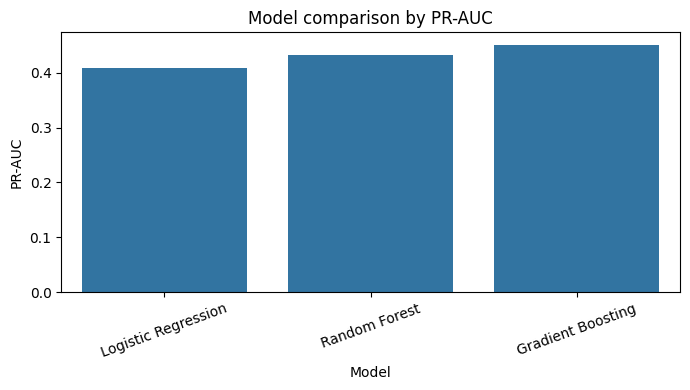

In [25]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=results,
    x="model",
    y="pr_auc"
)

plt.title("Model comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_pr_auc.png", dpi=300)
plt.show()

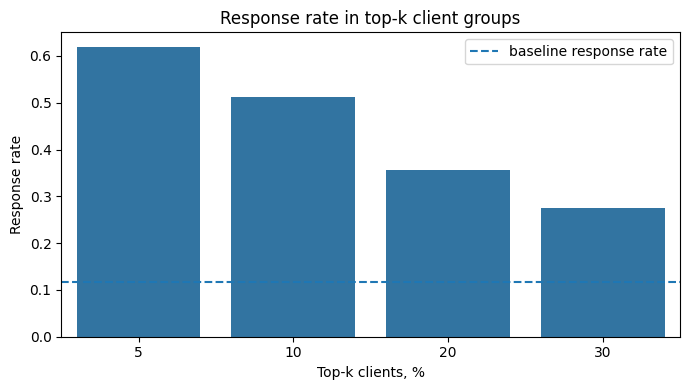

In [26]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=top_k_results,
    x="top_k_percent",
    y="response_rate"
)

plt.axhline(
    top_k_results["baseline_response_rate"].iloc[0],
    linestyle="--",
    label="baseline response rate"
)

plt.title("Response rate in top-k client groups")
plt.xlabel("Top-k clients, %")
plt.ylabel("Response rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_k_response_rate.png", dpi=300)
plt.show()

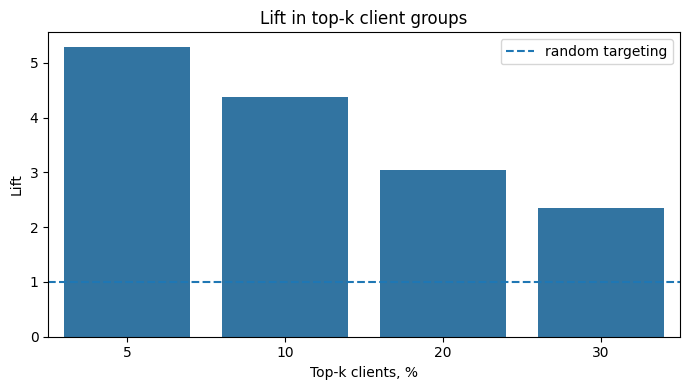

In [27]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=top_k_results,
    x="top_k_percent",
    y="lift"
)

plt.axhline(1, linestyle="--", label="random targeting")

plt.title("Lift in top-k client groups")
plt.xlabel("Top-k clients, %")
plt.ylabel("Lift")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_k_lift.png", dpi=300)
plt.show()